# WP-02 PoC — Audio Feature Extraction

**Goal:** Explore what metadata and acoustic features we can extract from tango MP3s, and decide what to keep in the production pipeline.

**Platform note:**
- **Windows:** librosa cells only — essentia has no Windows wheel
- **Mac/Linux:** run the essentia cells too and compare results

**Important:** This notebook is exploration-first. Do not lock in which features to keep here — feature selection is deferred until the agent feedback loop (WP-05/06) reveals which descriptors actually drive good tanda planning decisions.

---
Tracks used: `data/samples/` (34 tango + 2 cortina, committed to repo — no setup needed)

## 0. Imports & Setup

In [ ]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from mutagen.mp3 import MP3
from mutagen.id3 import ID3, TIT2, TPE1, TALB, TDRC, TRCK, TCON

# Essentia — Mac/Linux only
try:
    import essentia.standard as es
    ESSENTIA_AVAILABLE = True
    print("essentia available — essentia cells will run")
except ImportError:
    ESSENTIA_AVAILABLE = False
    print("essentia not available (Windows) — essentia cells will be skipped")

SAMPLES_DIR = Path('../data/samples')
tango_files = sorted([f for f in SAMPLES_DIR.glob('*.mp3') if 'Cortina' not in f.name and 'cortina' not in f.name.lower()])
all_files   = sorted(SAMPLES_DIR.glob('*.mp3'))

print(f"\nTango sample files ({len(tango_files)}):")
for f in tango_files:
    print(f"  {f.name}")

---
## 0b. Quick Listen — all sample tracks

Play any track before diving into feature extraction. Uses `IPython.display.Audio` — no extra dependencies.

In [ ]:
from IPython.display import Audio, display

print("=== All sample tracks ===\n")
for f in all_files:
    track_type = "cortina" if "cortina" in f.name.lower() else "tango"
    print(f"[{track_type.upper()}] {f.name}")
    display(Audio(str(f)))

---
## 1. Metadata Extraction with mutagen

Implementing `read_metadata()` here first. Will be moved to `atdj/audio/metadata.py` after validation.

In [ ]:
def read_metadata(file_path: str | Path) -> dict:
    """Read ID3 tags from MP3. If tags are missing, fields are left empty."""
    path = Path(file_path)
    result = {
        "file_path": str(path),
        "title": None,
        "orchestra": None,
        "album": None,
        "year": None,
        "decade": None,
        "track_number": None,
        "duration_seconds": None,
        "style": None,
    }
    try:
        audio = MP3(path)
        result["duration_seconds"] = round(audio.info.length, 2)
        tags = ID3(path)
        result["title"]        = str(tags.get("TIT2", path.stem))
        result["orchestra"]    = str(tags.get("TPE1", "")) or None
        result["album"]        = str(tags.get("TALB", "")) or None
        result["year"]         = str(tags.get("TDRC", "")) or None
        result["track_number"] = str(tags.get("TRCK", "")) or None
        # Genre / style from TCON tag
        genre_tag = tags.get("TCON")
        if genre_tag:
            result["style"] = str(genre_tag).strip().lower()
        # Compute decade from year
        if result["year"]:
            try:
                yr = int(str(result["year"])[:4])
                result["decade"] = f"{(yr // 10) * 10}s"
            except ValueError:
                pass
    except Exception:
        # Fallback: use filename as title, everything else stays None
        result["title"] = path.stem
    return result


# Test on all sample files
records = []
for f in all_files:
    meta = read_metadata(f)
    records.append(meta)

df_meta = pd.DataFrame(records)
print("Metadata extracted from ID3 tags:")
print("(style from TCON genre tag — empty if not present in file)")
df_meta

In [ ]:
# Observations:
# - Style (from TCON genre tag) is empty for most sample files — expected, since
#   La Fiesta CDs don't consistently tag genre in ID3
# - Year is also missing for most — only the backup cortina (Sucker) has it
# - Title and orchestra are reliably populated from ID3 tags
# - Decade is computed from year when available
# - In production: missing style/decade are left empty; backfilled separately
#   from TodoTango data (see Section 1b below)
print("Tag coverage:")
print(df_meta[['title','orchestra','year','style','decade']].isnull().sum())

---
## 1b. Batch Fix: Backfill Missing Style & Decade from TodoTango

**This is a one-time batch fix for our dataset, not production logic.**

The `read_metadata()` function above extracts style/decade from ID3 tags when available, but most of our La Fiesta CDs don't have genre tags. The TodoTango scraper notebook (`02_todotango_scraper.ipynb`) matched our tracks against the TodoTango database and saved the results in `todotango_enriched.csv`. Here we use that data to backfill missing style and decade values.

Cortinas get style auto-set to `"cortina"` based on their folder location (`data/cortinas/`).

In [ ]:
# Load TodoTango enriched data
tt_path = Path('../data/processed/todotango_enriched.csv')
df_tt = pd.read_csv(tt_path)
print(f"TodoTango enriched rows: {len(df_tt)}")
print(f"Match statuses:\n{df_tt['match_status'].value_counts()}")
print(f"\nGenre distribution (from TodoTango):\n{df_tt['genre'].value_counts()}")

In [ ]:
# Backfill: merge TodoTango genre → style, recording_year → decade
# into our sample metadata where these fields are missing

# Build lookup from filename → (genre, recording_year)
tt_lookup = df_tt.set_index('filename')[['genre', 'recording_year']].to_dict('index')

before_nulls = df_meta[['style', 'decade']].isnull().sum()

for i, row in df_meta.iterrows():
    fname = Path(row['file_path']).name
    if fname in tt_lookup:
        tt = tt_lookup[fname]
        # Backfill style from TodoTango genre (lowercased)
        if pd.isna(row['style']) and pd.notna(tt.get('genre')):
            df_meta.at[i, 'style'] = str(tt['genre']).strip().lower()
        # Backfill decade from recording_year
        if pd.isna(row['decade']) and pd.notna(tt.get('recording_year')):
            try:
                yr = int(tt['recording_year'])
                df_meta.at[i, 'decade'] = f"{(yr // 10) * 10}s"
            except (ValueError, TypeError):
                pass

after_nulls = df_meta[['style', 'decade']].isnull().sum()
print("=== Backfill results ===")
print(f"Style  — before: {before_nulls['style']} null → after: {after_nulls['style']} null")
print(f"Decade — before: {before_nulls['decade']} null → after: {after_nulls['decade']} null")
df_meta

In [ ]:
# Cortina handling: auto-set style to "cortina" for files in data/cortinas/
# In production, this is based on folder location — not filename heuristics
cortina_dir = Path('../data/cortinas')
for i, row in df_meta.iterrows():
    p = Path(row['file_path']).resolve()
    if cortina_dir.resolve() in p.parents or 'cortina' in p.name.lower():
        df_meta.at[i, 'style'] = 'cortina'

print("After cortina auto-set:")
print(df_meta[['title', 'style', 'decade']])

In [ ]:
# Style distribution chart — across full TodoTango enriched dataset
fig, ax = plt.subplots(figsize=(8, 4))
genre_counts = df_tt['genre'].value_counts()
genre_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Style Distribution (from TodoTango enrichment)')
ax.set_xlabel('Style / Genre')
ax.set_ylabel('Track Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTotal tracks with genre from TodoTango: {genre_counts.sum()}")
print(f"Tracks with no match (genre unknown): {df_tt['genre'].isna().sum()}")

In [ ]:
# Validation: check the 3 sample tango tracks
# - El Retirado: not in TodoTango (not_found) → style stays empty
# - Nobleza De Arrabal: Tango
# - Milongon: Milonga
print("=== Sample track validation ===")
for _, row in df_meta[~df_meta['title'].isin(['Dixieland Cortina', 'Sucker'])].iterrows():
    print(f"  {row['title']:25s}  style={str(row['style']):10s}  decade={str(row['decade'])}")

---
## 2. Feature Extraction — librosa

Exploring each feature individually before combining. Note what each value means for tango.

In [ ]:
# Load one track for detailed exploration
track_path = tango_files[0]
print(f"Exploring: {track_path.name}")
y, sr = librosa.load(track_path, sr=None)  # sr=None preserves original sample rate
print(f"Sample rate: {sr} Hz  |  Duration: {len(y)/sr:.1f}s  |  Samples: {len(y)}")

Exploring: 01 El Retirado.mp3


Sample rate: 44100 Hz  |  Duration: 144.4s  |  Samples: 6369408


In [ ]:
# Listen to the track being analyzed
print(f"Now analyzing: {track_path.name}")
display(Audio(data=y, rate=sr))

In [ ]:
# --- BPM ---
# Tango is typically 60-80 BPM (tango), 90-110 (milonga), 60-75 (vals)
tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
bpm = float(tempo[0]) if hasattr(tempo, '__len__') else float(tempo)
print(f"BPM: {bpm:.1f}")
print(f"Number of beats detected: {len(beats)}")
# Note: librosa sometimes returns half/double tempo — check if value is in expected range

BPM: 136.0
Number of beats detected: 314


Mean energy (RMS): 0.0809
Energy std dev:    0.0518  (higher = more dynamic)


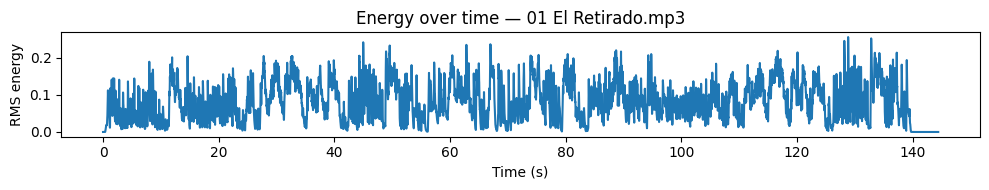

In [ ]:
# --- Energy (RMS) ---
# Higher = louder/more intense. Useful for energy arc planning.
rms = librosa.feature.rms(y=y)[0]
energy = float(np.mean(rms))
energy_std = float(np.std(rms))  # std = how much energy varies through the track
print(f"Mean energy (RMS): {energy:.4f}")
print(f"Energy std dev:    {energy_std:.4f}  (higher = more dynamic)")

# Plot energy over time
plt.figure(figsize=(10, 2))
frames = range(len(rms))
t = librosa.frames_to_time(frames, sr=sr)
plt.plot(t, rms)
plt.title(f'Energy over time — {track_path.name}')
plt.xlabel('Time (s)')
plt.ylabel('RMS energy')
plt.tight_layout()
plt.show()

In [ ]:
# --- Key Detection ---
# Tango is heavily minor-mode. Key helps group tracks that sound harmonically compatible.
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
chroma_mean = np.mean(chroma, axis=1)
note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
key_idx = int(np.argmax(chroma_mean))
key = note_names[key_idx]
print(f"Estimated key (dominant chroma): {key}")
print("Note: this is a rough estimate — chroma argmax doesn't distinguish major/minor")
print("Chroma profile:")
for n, v in zip(note_names, chroma_mean):
    print(f"  {n:3s}: {'█' * int(v * 20):.20s} {v:.3f}")

Estimated key (dominant chroma): E
Note: this is a rough estimate — chroma argmax doesn't distinguish major/minor
Chroma profile:
  C  : █████ 0.267
  C# : ███████ 0.352
  D  : █████████ 0.476
  D# : ████████ 0.405
  E  : ██████████ 0.510
  F  : ███████ 0.356
  F# : █████████ 0.494
  G  : ██████ 0.310
  G# : ██████ 0.338
  A  : ████████ 0.435
  A# : ███████ 0.356
  B  : ██████ 0.317


In [ ]:
# --- Brightness (Spectral Centroid) ---
# Higher = brighter/more treble. Older recordings tend to be darker (lower centroid).
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
brightness = float(np.mean(centroid))
print(f"Mean spectral centroid (brightness): {brightness:.1f} Hz")
print("Typical range: 500–3000 Hz for tango recordings")

Mean spectral centroid (brightness): 1277.8 Hz
Typical range: 500–3000 Hz for tango recordings


In [ ]:
# --- Additional spectral features (exploratory — not yet in schema) ---
# Keeping these for reference; whether they're useful depends on the agent feedback loop.

# Spectral rolloff: frequency below which X% of energy lies — proxy for muddiness
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
print(f"Spectral rolloff (mean): {np.mean(rolloff):.1f} Hz")

# Zero crossing rate: how often signal changes sign — proxy for noisiness / percussion
zcr = librosa.feature.zero_crossing_rate(y)[0]
print(f"Zero crossing rate (mean): {np.mean(zcr):.4f}")

# MFCCs: timbre fingerprint — not interpretable alone but useful for similarity
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfcc.shape}  (13 coefficients × {mfcc.shape[1]} frames)")
print("MFCC means:", np.mean(mfcc, axis=1).round(2))

Spectral rolloff (mean): 2458.1 Hz
Zero crossing rate (mean): 0.0425


MFCC shape: (13, 12441)  (13 coefficients × 12441 frames)
MFCC means: [-291.37  189.93  -32.32    0.67   24.74  -16.87   -8.85   -1.91  -12.25
   -7.28   -4.4    -6.84   -5.58]


In [ ]:
# --- Run across all 3 tango samples and compare ---
librosa_results = []
for f in tango_files:
    y, sr = librosa.load(f, sr=None)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    bpm = float(tempo[0]) if hasattr(tempo, '__len__') else float(tempo)
    rms   = librosa.feature.rms(y=y)[0]
    cent  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    key_idx = int(np.argmax(np.mean(chroma, axis=1)))
    librosa_results.append({
        "file": f.name,
        "bpm": round(bpm, 1),
        "energy": round(float(np.mean(rms)), 4),
        "brightness_hz": round(float(np.mean(cent)), 1),
        "key": note_names[key_idx],
    })

df_librosa = pd.DataFrame(librosa_results)
print("librosa results:")
df_librosa

librosa results:


,file,bpm,energy,brightness_hz,key
0,01 El Retirado.mp3,136.0,0.0809,1277.8,E
1,04 Nobleza De Arrabal.mp3,136.0,0.0805,1103.9,A
2,29 Milongon.mp3,101.3,0.0994,1287.1,C#


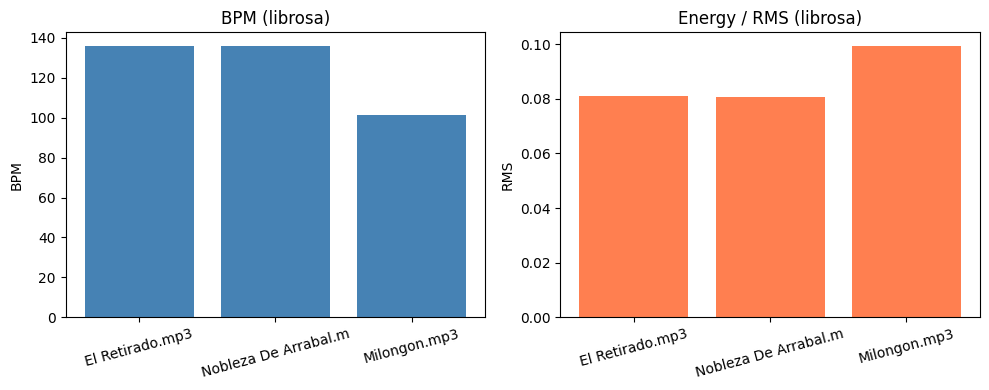

In [ ]:
# Bar chart — BPM and energy across tracks
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = [f.split(' ', 1)[-1][:20] for f in df_librosa['file']]

axes[0].bar(labels, df_librosa['bpm'], color='steelblue')
axes[0].set_title('BPM (librosa)')
axes[0].set_ylabel('BPM')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, df_librosa['energy'], color='coral')
axes[1].set_title('Energy / RMS (librosa)')
axes[1].set_ylabel('RMS')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---
## 3. Feature Extraction — essentia

> **Mac/Linux teammates:** run these cells and compare with the librosa results above.
> Install: `pip install essentia` (or `uv add essentia` on Mac/Linux).
> Windows: this section will be skipped automatically.

Key differences to watch for:
- `RhythmExtractor2013` vs librosa BPM — which is more accurate for tango?
- `KeyExtractor` gives key + scale (major/minor) — does it correctly identify minor-mode tango tracks?
- `Danceability` — does the score intuitively match how danceable each track feels?

In [ ]:
if not ESSENTIA_AVAILABLE:
    print("essentia not available on this platform — skipping section 3")
    print("Mac/Linux teammates: install essentia and re-run from this cell")
else:
    essentia_results = []
    for f in tango_files:
        loader = es.MonoLoader(filename=str(f))
        audio = loader()

        # BPM + beat positions
        rhythm = es.RhythmExtractor2013(method='multifeature')
        bpm, beats, bpm_confidence, _, bpm_intervals = rhythm(audio)

        # Key + scale (major/minor)
        key_extractor = es.KeyExtractor()
        key, scale, key_strength = key_extractor(audio)

        # Energy
        energy = es.Energy()(audio)

        # Danceability
        danceability, dfa = es.Danceability()(audio)

        # Loudness
        loudness = es.Loudness()(audio)

        essentia_results.append({
            "file": f.name,
            "bpm": round(float(bpm), 1),
            "bpm_confidence": round(float(bpm_confidence), 2),
            "key": key,
            "scale": scale,
            "key_strength": round(float(key_strength), 3),
            "energy": round(float(energy), 4),
            "loudness_db": round(float(loudness), 2),
            "danceability": round(float(danceability), 3),
        })

    df_essentia = pd.DataFrame(essentia_results)
    print("essentia results:")
    df_essentia

essentia not available on this platform — skipping section 3
Mac/Linux teammates: install essentia and re-run from this cell


In [ ]:
# Side-by-side comparison (runs only if essentia is available)
if not ESSENTIA_AVAILABLE:
    print("Skipped — essentia not available")
else:
    print("=== BPM comparison ===")
    for i, f in enumerate(tango_files):
        lb = df_librosa.loc[i, 'bpm']
        es_bpm = df_essentia.loc[i, 'bpm']
        print(f"  {f.name[:30]:30s}  librosa={lb:6.1f}  essentia={es_bpm:6.1f}  diff={abs(lb-es_bpm):.1f}")

    print("\n=== Key comparison ===")
    for i, f in enumerate(tango_files):
        lb_key = df_librosa.loc[i, 'key']
        es_key = df_essentia.loc[i, 'key']
        es_scale = df_essentia.loc[i, 'scale']
        print(f"  {f.name[:30]:30s}  librosa={lb_key:3s}  essentia={es_key} {es_scale}")

Skipped — essentia not available
